In [8]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from RBMS import GaussianRBM
from helpers import find_project_dir, sample_gaussian_rbm, read_data
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
rng = np.random.default_rng(42)

In [9]:
X, X_raw, real_den, dates, species = read_data()
T, n_vis = X.shape
print(f"Dataset: {T} time steps, {n_vis} species")

Dataset: 2066 time steps, 81 species


RBM train: 1652 days  |  val: 414 days  (random split)


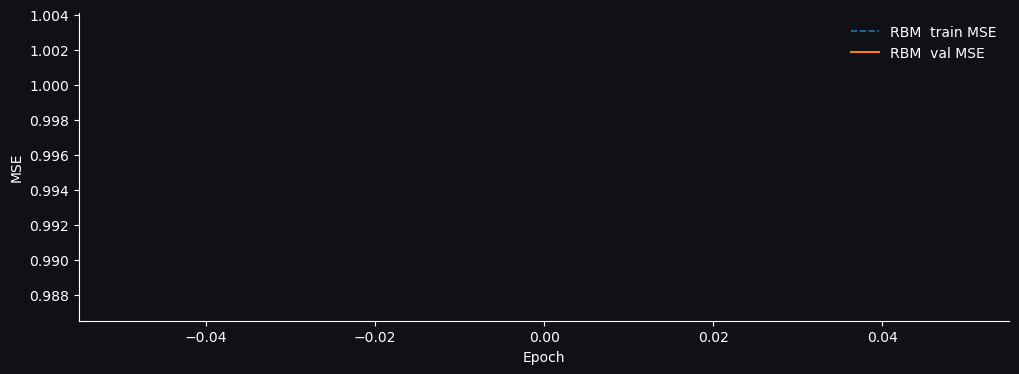

In [11]:
rbm_perm      = rng.permutation(T)
rbm_split     = int(0.8 * T)
rbm_train_idx = rbm_perm[:rbm_split]
rbm_val_idx   = rbm_perm[rbm_split:]
X_rbm_train   = X[rbm_train_idx]
X_rbm_val     = X[rbm_val_idx]
print(f'RBM train: {len(X_rbm_train)} days  |  val: {len(X_rbm_val)} days  (random split)')

# ── Training ──────────────────────────────────────────────────────────────────
RBM_HIDDEN   = 2    # same capacity as the cRBM for fair comparison
RBM_EPOCHS   = 1
RBM_LR       = 5e-4
RBM_PATIENCE = 150
RBM_BATCH    = 32

rbm           = GaussianRBM(n_vis, RBM_HIDDEN, lr=RBM_LR, momentum=0.9, l2=1e-4)
rbm_train_his = []
rbm_val_his   = []
rbm_best_val  = np.inf
rbm_best_snap = None
rbm_no_imp    = 0

for epoch in range(RBM_EPOCHS):
    mse_epoch = []
    idx = rng.permutation(len(X_rbm_train))

    for batch_start in range(0, len(idx), RBM_BATCH):
        batch = idx[batch_start : batch_start + RBM_BATCH]
        dW  = np.zeros_like(rbm.W)
        dbh = np.zeros_like(rbm.bh)
        dbv = np.zeros_like(rbm.bv)
        b_mse = []

        for t in batch:
            v  = X_rbm_train[t]
            hp = rbm.h_given_v(v)
            hs = (rng.random(rbm.nh) < hp).astype(np.float32)   # CD-1 sample
            vn = rbm.v_given_h(hs)
            hn = rbm.h_given_v(vn)
            dW  += np.outer(hp, v) - np.outer(hn, vn)
            dbh += hp - hn
            dbv += v  - vn
            v_mf = rbm.v_given_h(hp)                             # mean-field recon
            b_mse.append(float(np.mean((v - v_mf) ** 2)))

        n = len(batch); lr = rbm.lr
        rbm._dW  = rbm.mom * rbm._dW  + lr * (dW/n  - rbm.l2 * rbm.W)
        rbm._dbh = rbm.mom * rbm._dbh + lr * (dbh/n)
        rbm._dbv = rbm.mom * rbm._dbv + lr * (dbv/n)
        rbm.W  += rbm._dW;  rbm.bh += rbm._dbh;  rbm.bv += rbm._dbv
        mse_epoch.extend(b_mse)

    rbm_train_his.append(float(np.mean(mse_epoch)))

    # ── Val reconstruction MSE ────────────────────────────────────────────────
    val_errs = [float(np.mean((X_rbm_val[t] - rbm.v_given_h(rbm.h_given_v(X_rbm_val[t]))) ** 2))
                for t in range(len(X_rbm_val))]
    v_mse = float(np.mean(val_errs))
    rbm_val_his.append(v_mse)

    if v_mse < rbm_best_val:
        rbm_best_val  = v_mse
        rbm_best_snap = copy.deepcopy(rbm)
        rbm_no_imp    = 0
    else:
        rbm_no_imp += 1

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1:4d}  |  train MSE = {rbm_train_his[-1]:.4f}'
              f'  |  val MSE = {v_mse:.4f}'
              f'  |  best val = {rbm_best_val:.4f}'
              f'  |  patience = {rbm_no_imp}/{RBM_PATIENCE}')

    if rbm_no_imp >= RBM_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

rbm = rbm_best_snap


# Save the model to a npz file after training
np.savez_compressed("rbm_model.npz", W=rbm.W, bh=rbm.bh, bv=rbm.bv)

fig, ax = plt.subplots(figsize=(12, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
ax.plot(rbm_train_his, linewidth=1.2, linestyle='--', label='RBM  train MSE')
ax.plot(rbm_val_his, linewidth=1.5, label='RBM  val MSE')
ax.set_xlabel('Epoch', color="white", fontsize=10)
ax.set_ylabel('MSE', color ="white", fontsize=10)
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.legend(loc='upper right', frameon=False, fontsize=10, labelcolor='white')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color('white')
plt.show()

In [ ]:
H_real      = rbm.encode(X)
X_real_log  = X_raw                                      # log10, not z-scored
rbm_species = species
dates_real  = pd.DatetimeIndex(dates)
months_real = np.array([d.month for d in dates_real])

season_map = {
    12: 'Winter',  1: 'Winter',  2: 'Winter',
     3: 'Spring',  4: 'Spring',  5: 'Spring',
     6: 'Summer',  7: 'Summer',  8: 'Summer',
     9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}

Silhouette-optimal K = 2  |  Using K = 2

Ecological-state summary from RBM latent space:
State  Days  % total Dominant season  Mean total density                                                                                        Top enriched taxa
   S0   887     42.9          Winter              0.0509            dinoflagellate diamond, bosmina, aulacoseira, centric diatom, synchaeta, synedra angustissima
   S1  1179     57.1          Autumn              0.0655 chroococcales, dinobryon, plankton z, coelosphaerium, chlorophyte frame, cyanobacteria colonial probably


/var/folders/rq/k6q5m5x57ggcclsdrpv0g4j00000gn/T/ipykernel_55947/897936669.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


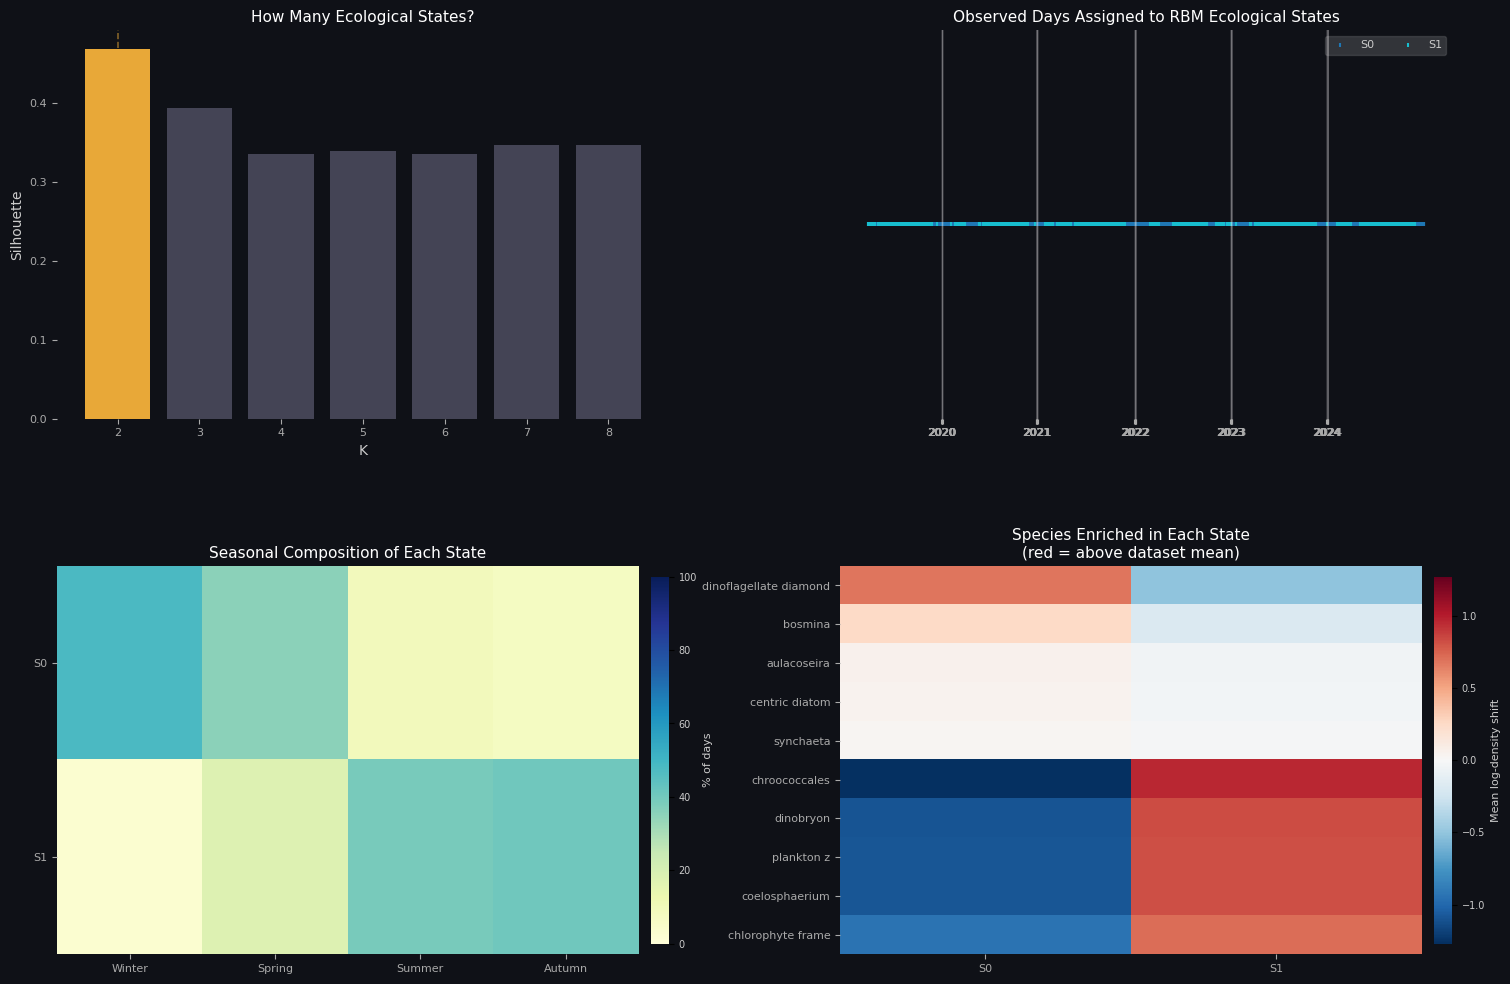

These states come from clustering the RBM hidden activations of real observed days; they are ecological assemblage states, not temporal transition states.


In [6]:
RBM_K_OVERRIDE = None     
RBM_K_RANGE    = range(2, 9)

sil_scores = []
inertias   = []
for k in RBM_K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(H_real)
    sil_scores.append(silhouette_score(H_real, lbl))
    inertias.append(km.inertia_)

auto_k   = list(RBM_K_RANGE)[int(np.argmax(sil_scores))]
n_states = RBM_K_OVERRIDE if RBM_K_OVERRIDE is not None else auto_k
print(f'Silhouette-optimal K = {auto_k}  |  Using K = {n_states}')

km_states = KMeans(n_clusters=n_states, random_state=42, n_init=20)
rbm_state = km_states.fit_predict(H_real)
state_H   = np.stack([H_real[rbm_state == k].mean(0) for k in range(n_states)])
state_log = np.stack([X_real_log[rbm_state == k].mean(0) for k in range(n_states)])
state_diff = state_log - X_real_log.mean(axis=0, keepdims=True)
state_total = np.array([real_den[rbm_state == k].sum(axis=1).mean() for k in range(n_states)])

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
seasons_real = np.array([season_map[m] for m in months_real])
state_season = np.zeros((n_states, len(season_order)), dtype=float)
summary_rows = []
for k in range(n_states):
    mask = rbm_state == k
    for i, s in enumerate(season_order):
        state_season[k, i] = 100 * np.mean(seasons_real[mask] == s)
    dom_season = season_order[int(np.argmax(state_season[k]))]
    top_idx = np.argsort(state_diff[k])[-6:][::-1]
    summary_rows.append({
        'State': f'S{k}',
        'Days': int(mask.sum()),
        '% total': round(100 * mask.sum() / len(rbm_state), 1),
        'Dominant season': dom_season,
        'Mean total density': round(float(state_total[k]), 4),
        'Top enriched taxa': ', '.join(rbm_species[i].replace('_', ' ') for i in top_idx),
    })

state_df = pd.DataFrame(summary_rows)
print('\nEcological-state summary from RBM latent space:')
print(state_df.to_string(index=False))

species_idx = []
for k in range(n_states):
    species_idx.extend(np.argsort(state_diff[k])[-5:][::-1].tolist())
species_idx = list(dict.fromkeys(species_idx))
dom_state   = np.argmax(state_diff[:, species_idx], axis=0)
dom_score   = state_diff[:, species_idx][dom_state, np.arange(len(species_idx))]
order       = np.lexsort((-dom_score, dom_state))
species_idx = [species_idx[i] for i in order]
species_lab = [rbm_species[i].replace('_', ' ') for i in species_idx]

PAL = plt.cm.tab10(np.linspace(0, 0.9, n_states))
fig = plt.figure(figsize=(18, 12), facecolor='#0f1117')
gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.28)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
for ax in [ax0, ax1, ax2, ax3]:
    ax.set_facecolor('#0f1117')

bar_colors = ['#e8a838' if k == n_states else '#444455' for k in RBM_K_RANGE]
ax0.bar(list(RBM_K_RANGE), sil_scores, color=bar_colors, edgecolor='none')
ax0.axvline(n_states, color='#e8a83888', linestyle='--', linewidth=1.2)
ax0.set_xlabel('K', color='#cccccc')
ax0.set_ylabel('Silhouette', color='#cccccc')
ax0.set_title('How Many Ecological States?', color='white', fontsize=11)
ax0.set_xticks(list(RBM_K_RANGE))
ax0.tick_params(colors='#aaaaaa', labelsize=8)

day_idx = np.arange(len(dates_real))
for k in range(n_states):
    mask = rbm_state == k
    ax1.scatter(day_idx[mask], np.zeros(mask.sum()), c=[PAL[k]], s=8, marker='|', label=f'S{k}')
jan_pos = [i for i, d in enumerate(dates_real) if d.month == 1 and d.day <= 7]
jan_lbl = [str(dates_real[i].year) for i in jan_pos]
ax1.set_xticks(jan_pos)
ax1.set_xticklabels(jan_lbl, color='#cccccc', fontsize=8)
for xi in jan_pos:
    ax1.axvline(xi, color='#ffffff22', linewidth=0.7)
ax1.set_yticks([])
ax1.set_title('Observed Days Assigned to RBM Ecological States', color='white', fontsize=11)
ax1.legend(fontsize=8, framealpha=0.15, labelcolor='#cccccc', ncol=min(4, n_states), loc='upper right')

im2 = ax2.imshow(state_season, aspect='auto', cmap='YlGnBu', vmin=0, vmax=100)
ax2.set_xticks(range(len(season_order)))
ax2.set_xticklabels(season_order, color='#cccccc', fontsize=9)
ax2.set_yticks(range(n_states))
ax2.set_yticklabels([f'S{k}' for k in range(n_states)], color='#cccccc', fontsize=9)
ax2.set_title('Seasonal Composition of Each State', color='white', fontsize=11)
cb2 = fig.colorbar(im2, ax=ax2, fraction=0.03, pad=0.02)
cb2.set_label('% of days', color='#cccccc', fontsize=8)
cb2.ax.yaxis.set_tick_params(labelsize=7)
plt.setp(cb2.ax.yaxis.get_ticklabels(), color='#cccccc')
cb2.outline.set_visible(False)

vabs = np.abs(state_diff[:, species_idx]).max()
im3 = ax3.imshow(state_diff[:, species_idx].T, aspect='auto', cmap='RdBu_r', vmin=-vabs, vmax=vabs)
ax3.set_xticks(range(n_states))
ax3.set_xticklabels([f'S{k}' for k in range(n_states)], color='#cccccc', fontsize=9)
ax3.set_yticks(range(len(species_idx)))
ax3.set_yticklabels(species_lab, color='#cccccc', fontsize=6.5)
ax3.set_title('Species Enriched in Each State\n(red = above dataset mean)', color='white', fontsize=11)
cb3 = fig.colorbar(im3, ax=ax3, fraction=0.03, pad=0.02)
cb3.set_label('Mean log-density shift', color='#cccccc', fontsize=8)
cb3.ax.yaxis.set_tick_params(labelsize=7)
plt.setp(cb3.ax.yaxis.get_ticklabels(), color='#cccccc')
cb3.outline.set_visible(False)

for ax in [ax0, ax1, ax2, ax3]:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#aaaaaa', labelsize=8)

plt.tight_layout()
plt.show()
print('These states come from clustering the RBM hidden activations of real observed days; they are ecological assemblage states, not temporal transition states.')


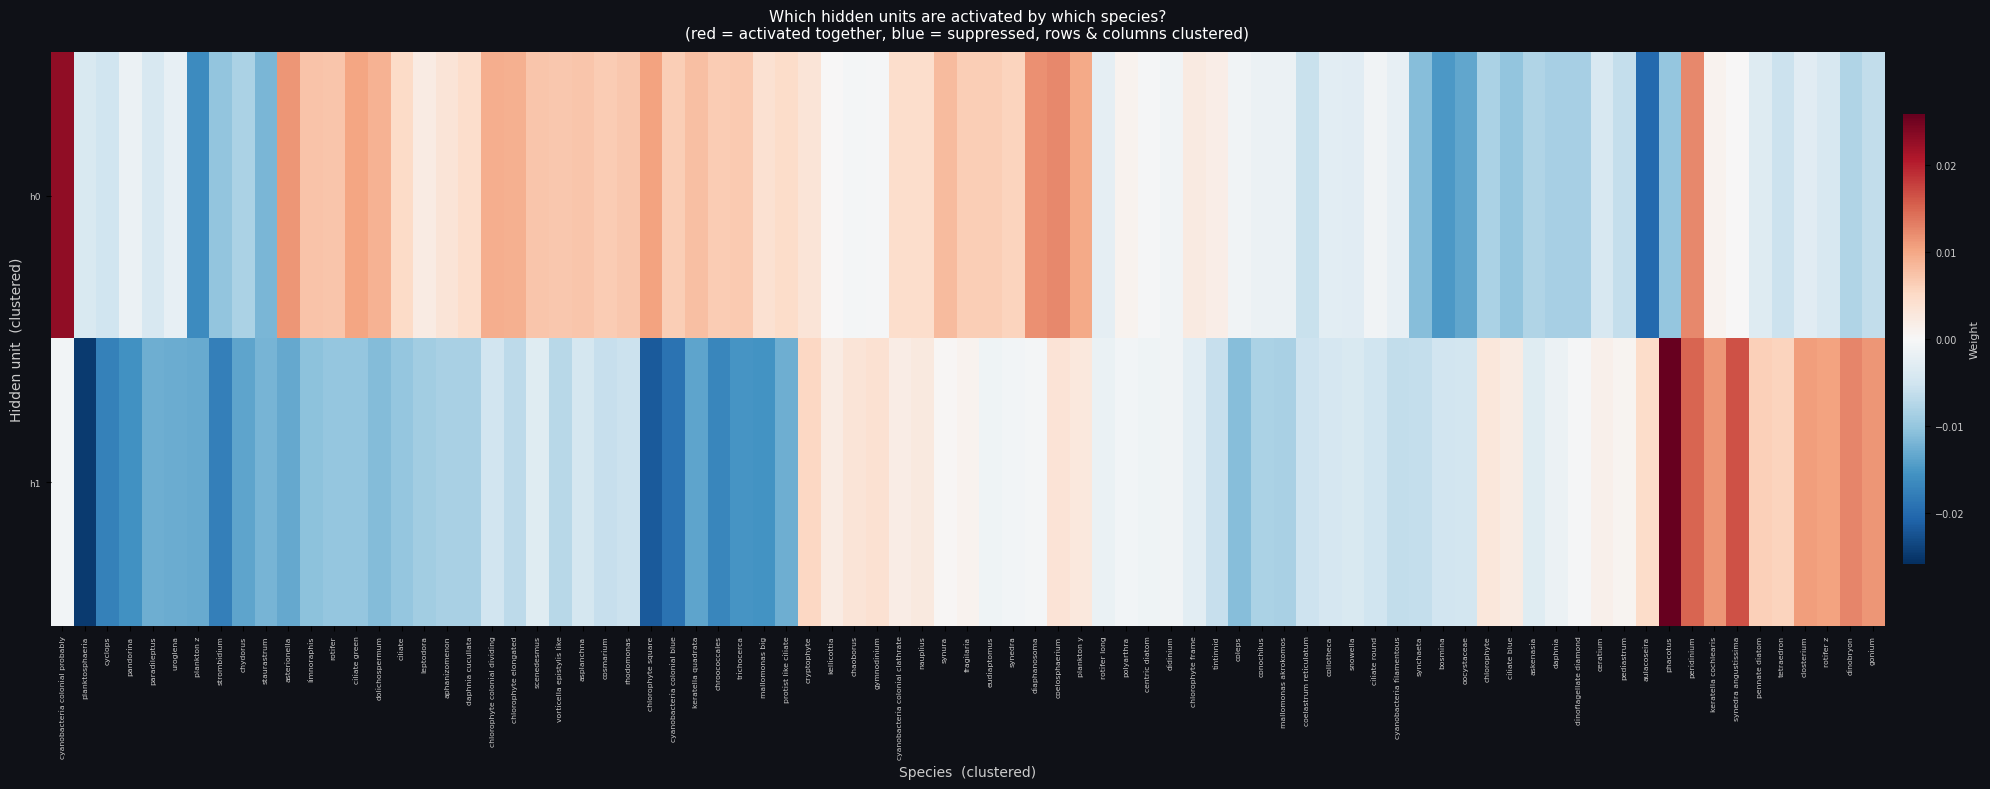

In [7]:
# ── Bi-cluster W for readability ──────────────────────────────────────────────
W = rbm.W   # (n_hidden, n_species)

# cluster hidden units by their weight profiles
row_order = leaves_list(linkage(W,   method='average'))
# cluster species by their weight profiles across hidden units
col_order = leaves_list(linkage(W.T, method='average'))

W_ord      = W[np.ix_(row_order, col_order)]
sp_labels  = [rbm_species[i].replace('_', ' ') for i in col_order]
hu_labels  = [f'h{i}' for i in row_order]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_h = max(8, len(row_order) * 0.11)
fig, ax = plt.subplots(figsize=(20, fig_h), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

vmax = np.abs(W_ord).max()
im   = ax.imshow(W_ord, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(col_order)))
ax.set_xticklabels(sp_labels, rotation=90, fontsize=5.5, color='#cccccc')
ax.set_yticks(range(len(row_order)))
ax.set_yticklabels(hu_labels, fontsize=6.5, color='#cccccc')
ax.set_xlabel('Species  (clustered)', color='#cccccc', fontsize=10)
ax.set_ylabel('Hidden unit  (clustered)', color='#cccccc', fontsize=10)
ax.set_title('Which hidden units are activated by which species?\n'
             '(red = activated together, blue = suppressed, rows & columns clustered)',
             color='white', fontsize=11, pad=10)
for spine in ax.spines.values():
    spine.set_visible(False)

cb = fig.colorbar(im, ax=ax, fraction=0.012, pad=0.01)
cb.set_label('Weight', color='#cccccc', fontsize=8)
cb.ax.yaxis.set_tick_params(labelsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#cccccc')
cb.outline.set_visible(False)

plt.tight_layout()
plt.savefig('rbm_weights_biclustered.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()